In [1]:
import sys
import warnings
sys.path.insert(0, '../') # Trick to import code from parent folder
import cmip6_archive as ca
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xesmf as xe
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter, PercentFormatter
import colormaps as cmaps

In [2]:
# Common 1º x 1º grid to compute the MME later
common_grid = xr.Dataset({
        "lat": ("lat", np.arange(-89.5, 90.0, 1.0)),
        "lon": ("lon", np.arange(0.5, 360.0, 1.0)),
})

BASELINE_YEARS = slice(1981, 2000)   # matches the 90th-percentile reference period
FUTURE_YEARS = slice(2071, 2100)

# Ignore repeated warnings after the first occurrence
warnings.filterwarnings("once")

In [3]:
def regrid(ds_in, regrid_to, method="conservative", skipna=False):
    """Convenience function for one-time regridding. Regrids data in `ds_in` to the grid used in `regrid_to`."""
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True) # When dealing with global grids, we need to set periodic=True, otherwise data along the meridian line will be missing.
    ds_out = regridder(ds_in, skipna=skipna)
    return ds_out

def calculate_anomalies_all_models(ref_grid_ds, anom_type = "absolute"):
    # This function is adapted from https://projectpythia.org/cmip6-cookbook/notebooks/example-workflows/xesmf-ohu/
    # Credit goes to R. Abernathey, H. Drake, R. R. Ford, M. Grover, and Project Pythia contributors (2026)

    print(f"Calculating {anom_type} anomalies for {len(ca.MODELS)} models...")
    
    ds_regrid_dict = {}
    success_count = 0
    model_count = 0

    for model in ca.MODELS:
        try:
            # 1. Find anomaly with respect to historical baseline for all thirstwave metrics (intensity, frequency, etc.)
            ds_historical = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp='historical').sel(year=BASELINE_YEARS)
            ds_ssp585 = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp='ssp585').sel(year=FUTURE_YEARS)
            
            baseline = ds_historical.mean(dim='year')
            end_of_century = ds_ssp585.mean(dim='year')

            if anom_type == "absolute":
                anomaly = (end_of_century - baseline) # Absolute change
            elif anom_type == "relative":
                anomaly = (end_of_century - baseline) / baseline # Relative change (%)
            else:
                raise ValueError("anom_type should be either 'absolute' or 'relative")

            # 2. Mask out grid cells with < 5% land
            land_area_fraction = ca.LAND_MASKS_ARCHIVE.open(model=model, exp='piControl')['sftlf']
            mask = (land_area_fraction >= 5).values
            anomaly = anomaly.where(mask)
            anomaly["mask"] = (('lat', 'lon'), mask) # We add the mask data to the Dataset so the regridding doesn't treat NaNs like regular data (see https://pangeo-xesmf.readthedocs.io/en/latest/notebooks/Masking.html#)


            # 3. Regrid to the common grid
            anomaly_regridded = regrid(anomaly, ref_grid_ds, method="conservative", skipna=True)
            if 'type' in anomaly_regridded.coords:
                anomaly_regridded = anomaly_regridded.drop_vars("type")

        except Exception as e:
            print('Failed to regrid '+model+': '+str(e))
        
        else: 
            ds_regrid_dict[model]= anomaly_regridded
            print(model+' regridded and added to dictionary')
            success_count += 1
        finally:
            model_count += 1
            
    print('-'*40+'\n| '+str(success_count)+'/'+str(model_count)+' models successfully regridded! |\n'+'-'*40)

    # Dataset with all models (absolute anomaly)
    ds = list(ds_regrid_dict.values())
    coord = list(ds_regrid_dict.keys())
    ds_out_regrid = xr.concat(objs=ds, dim=coord, coords='all').rename({'concat_dim':'model'})

    return ds_out_regrid

ds_out_regrid = calculate_anomalies_all_models(common_grid, anom_type="relative")
ds_out_regrid_abs = calculate_anomalies_all_models(common_grid, anom_type="absolute")

Calculating relative anomalies for 8 models...


<frozen importlib._bootstrap>:491: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


IPSL-CM6A-LR regridded and added to dictionary
MIROC6 regridded and added to dictionary
MRI-ESM2-0 regridded and added to dictionary


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


...

IPSL-CM6A-LR regridded and added to dictionary
MIROC6 regridded and added to dictionary
MRI-ESM2-0 regridded and added to dictionary


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


NorESM2-LM regridded and added to dictionary


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


NorESM2-MM regridded and added to dictionary
MPI-ESM1-2-HR regridded and added to dictionary
MPI-ESM1-2-LR regridded and added to dictionary
UKESM1-0-LL regridded and added to dictionary
----------------------------------------
| 8/8 models successfully regridded! |
----------------------------------------


In [4]:
multi_model_mean = ds_out_regrid.mean(dim='model')
multi_model_mean_abs = ds_out_regrid_abs.mean(dim='model')

frequency = multi_model_mean['event_count'].load() * 100
intensity = multi_model_mean['intensity'].load() * 100
duration = multi_model_mean['mean_duration'].load() * 100
rad_frac = multi_model_mean_abs['rad_frac_tw'].load()

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


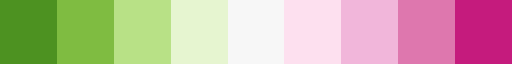

In [5]:
CMAP = cmaps.piyg_r
CMAP

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp

  ✓ end_of_century_anom.png
  ✓ end_of_century_anom.pdf


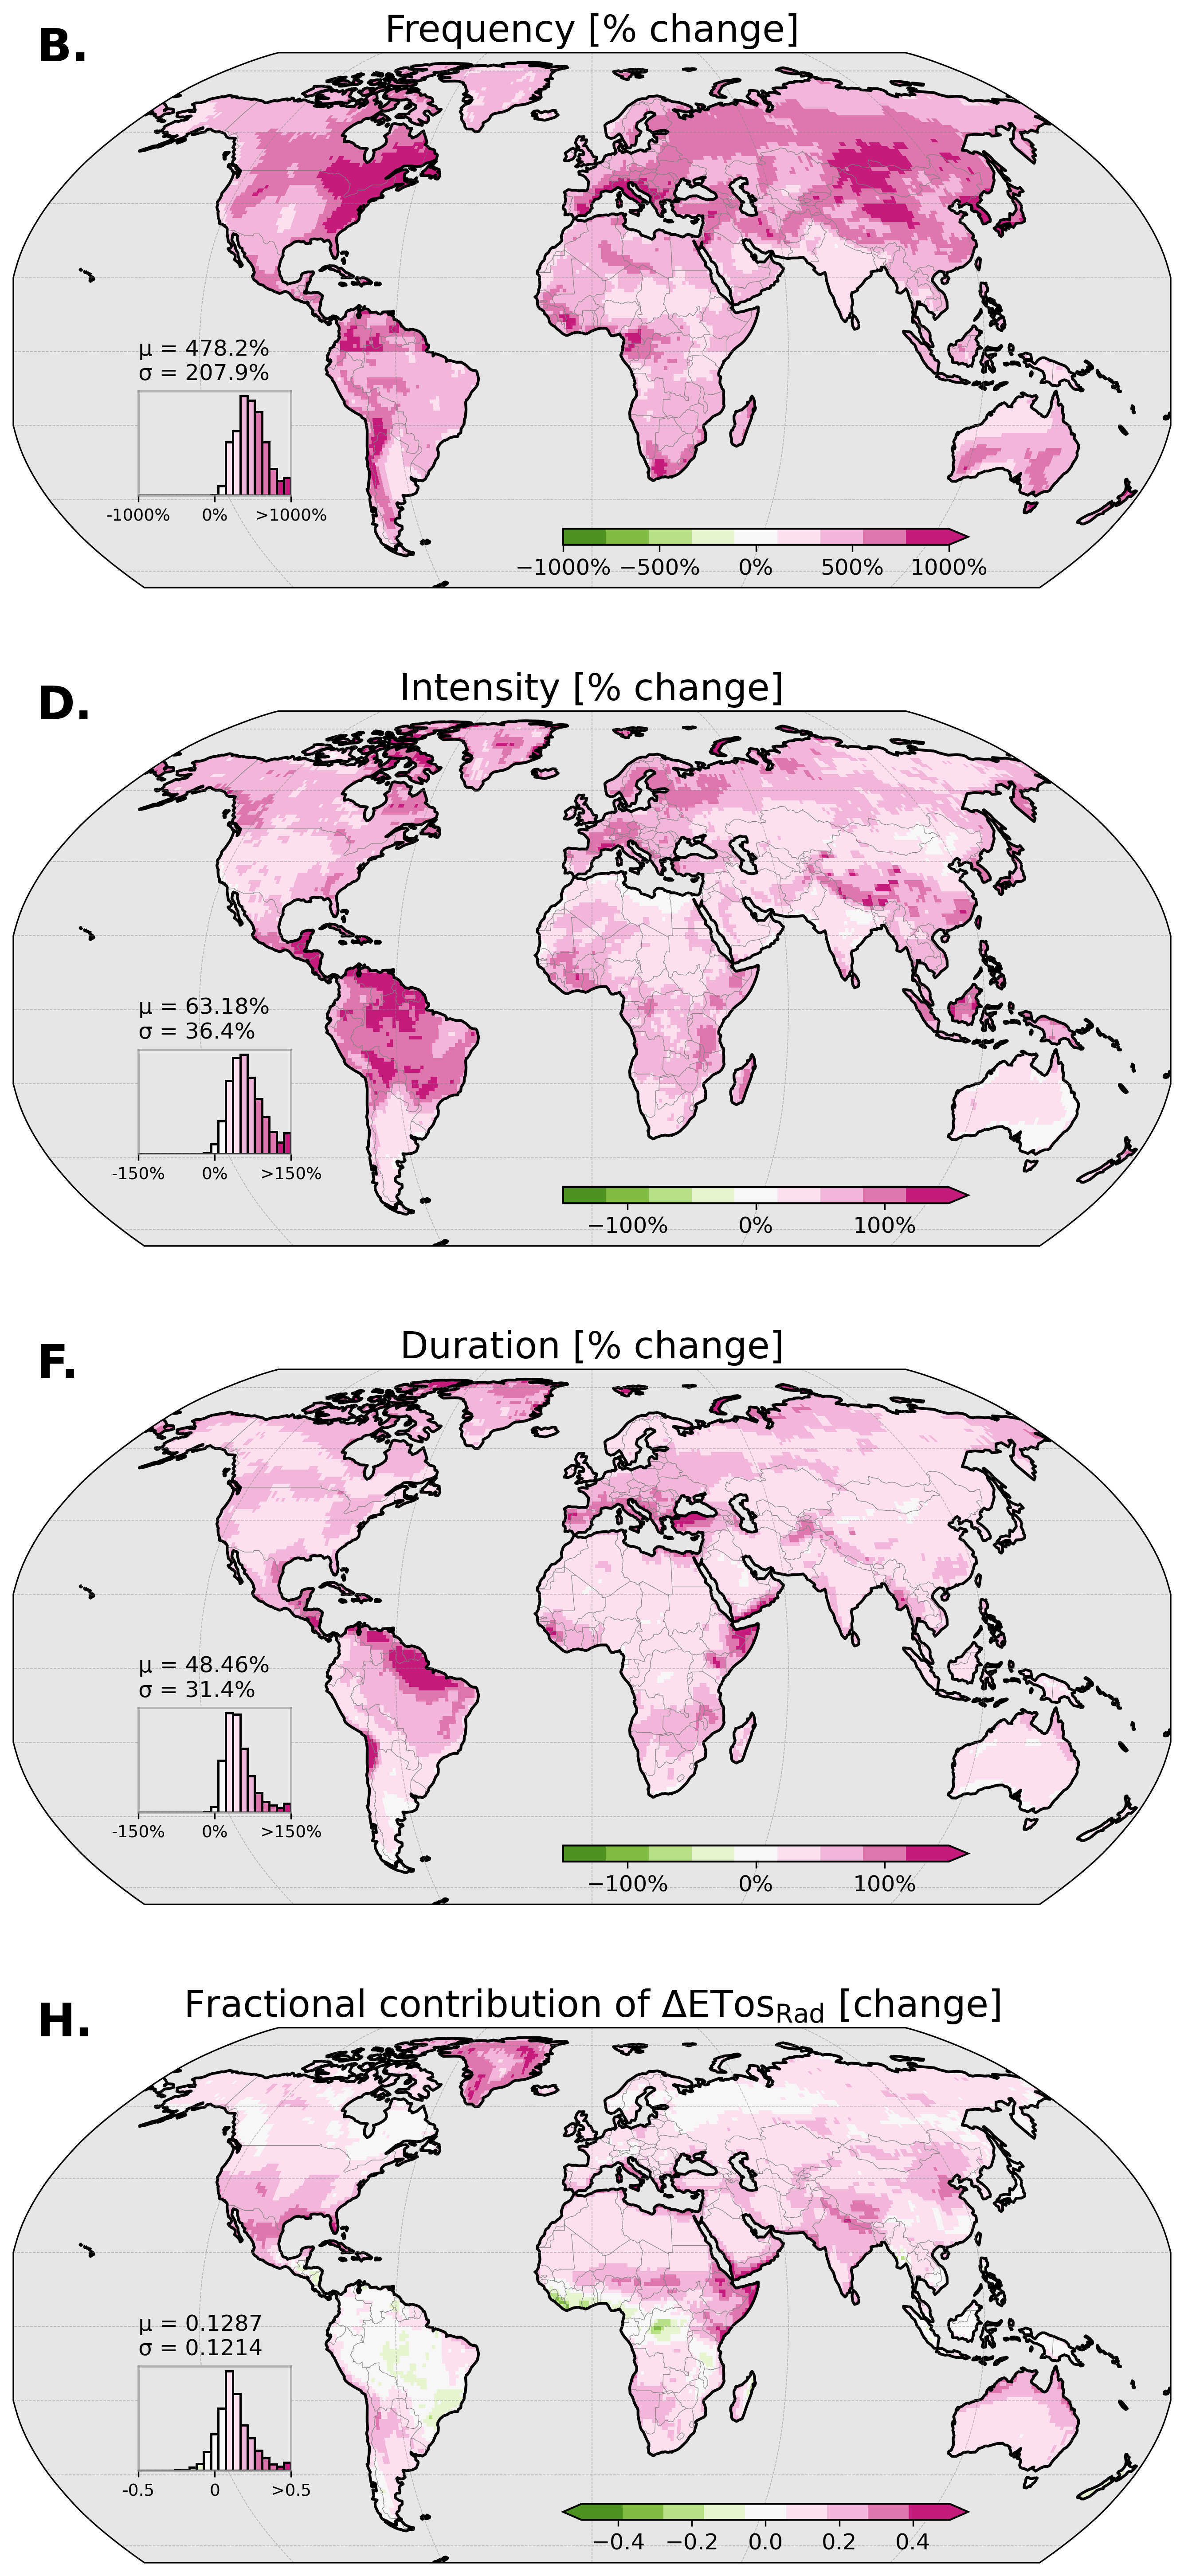

In [8]:
# ============================================================
# formatting helpers for relative (%) vs. absolute panels
# ============================================================
def _fold_change_formatter(value, _pos=None):
    """Turn a %-change value (e.g. 400, meaning +400%) into a fold-change
    label (e.g. '×5'). Floors at ×0 since a relative change can't go below
    -100% (you can't lose more than everything you started with) -- so
    every value <= -100% collapses to the same '×0' label. That's the
    tradeoff of this style: it reads intuitively near 0, but throws away
    resolution on the negative side of a wide colorbar like panel A's
    (vmin=-1000). Percent style keeps that resolution; pick per panel.
    """
    fold = max(1 + value / 100.0, 0.0)
    return f"×{fold:g}"


def _format_edge_label(value, anom_type, relative_style):
    if anom_type == "relative":
        return _fold_change_formatter(value) if relative_style == "fold" else f"{value:.0f}%"
    return f"{value:.3g}"


# ============================================================
# 4. plotting helper
# ============================================================
def plot_panel(ax, plot_grid, title, vmin, vmax, cmap, extend="max", label="",
                anom_type="absolute", relative_style="percent"):
    """
    anom_type : "absolute" or "relative"
        "absolute": behaves exactly like the original function -- plain
        numeric ticks, title suffixed with `unit` (e.g. "mm day-1").
        "relative": `plot_grid` is assumed to already be a %-change (i.e.
        multiplied by 100 upstream, as frequency/intensity/duration are
        here). Colorbar + histogram ticks are relabeled as percent (default)
        or, if relative_style="fold", as a fold-change like "×5". The title
        is suffixed with "[% change]" instead of `unit`, so a physical unit
        never gets attached to a relative quantity by mistake -- this was
        the actual bug in panels A-C of the original figure (titled
        "event/year", "mm/day", "days/event" while plotting %-change data).
    relative_style : "percent" or "fold", only used when anom_type="relative".
    """
    if anom_type not in ("absolute", "relative"):
        raise ValueError("anom_type must be 'absolute' or 'relative'")

    LON, LAT = plot_grid.lon.values, plot_grid.lat.values
    plot_grid = plot_grid.values
    im = ax.pcolormesh(
        LON, LAT, plot_grid,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax
    )

    ax.set_extent([-180, 180, -65, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, color="0.9", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="gray")
    ax.coastlines(linewidth=1.5)
    ax.text(
        0.02, 1.05, label,
        transform=ax.transAxes,
        fontsize=25,
        fontweight='bold',
        va='top',
        ha='left'
    )
    # ========================================================
    # inset colorbar
    # ========================================================
    cax = inset_axes(
        ax,
        width="35%",
        height="3%",
        loc='lower center',
        bbox_to_anchor=(0.15, 0.08, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cb = plt.colorbar(
        im,
        cax=cax,
        orientation="horizontal",
        extend=extend
    )

    # FIX: this is the actual "-100% / ×10 instead of a bare number" ask.
    if anom_type == "relative":
        if relative_style == "fold":
            cb.ax.xaxis.set_major_formatter(FuncFormatter(_fold_change_formatter))
        else:
            cb.ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    # anom_type == "absolute": leave the default numeric formatter as-is

    cb.ax.tick_params(labelsize=12)
    cb.ax.xaxis.set_label_position('top')
    cb.ax.xaxis.set_ticks_position('bottom')
    cb.outline.set_linewidth(1)
    cb.outline.set_edgecolor("black")
    cax.patch.set_alpha(0.8)

    ax.set_title(title, fontsize=20)

    # ========================================================
    # inset histogram (area-weighted)
    # ========================================================
    if np.ndim(LAT) == 1:
        lat2d = np.repeat(LAT[:, None], plot_grid.shape[1], axis=1)
    else:
        lat2d = LAT

    weights = np.cos(np.deg2rad(lat2d))

    # FIX: the next three lines were duplicated verbatim right below
    # themselves in the original (no effect on the result, just wasted
    # cycles) -- removed the redundant copy.
    valid_mask = np.isfinite(plot_grid) & np.isfinite(weights)
    valid_data = plot_grid[valid_mask].flatten()
    valid_weights = weights[valid_mask].flatten()

    # Don't drop out-of-range values -- clip them into the edge bins instead
    global_mean = np.sum(valid_data * valid_weights) / np.sum(valid_weights)
    weighted_squared_diff = np.sum(valid_weights * (valid_data - global_mean) ** 2) / np.sum(valid_weights)
    global_std = np.sqrt(weighted_squared_diff)
    valid_data = np.clip(valid_data, vmin, vmax)

    if len(valid_data) > 0:
        normalized_weights = valid_weights / np.sum(valid_weights)

        inset_ax = inset_axes(
            ax,
            width="12%",
            height="15%",
            loc="lower left",
            bbox_to_anchor=(0.1, 0.155, 1.1, 1.3),
            bbox_transform=ax.transAxes
        )

        bins = np.linspace(vmin, vmax, 22)

        hist_vals, bin_edges, patches = inset_ax.hist(
            valid_data,
            bins=bins,
            weights=normalized_weights,
            density=True,
            edgecolor="black",
            linewidth=1.2
        )

        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        for patch, center in zip(patches, bin_centers):
            patch.set_facecolor(cmap(norm(center)))

        inset_ax.tick_params(labelsize=9)
        inset_ax.get_yaxis().set_visible(False)

        for spine in inset_ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("gray")
            spine.set_alpha(0.5)

        inset_ax.set_xlim(vmin, vmax)
        xticks = np.linspace(vmin, vmax, 3)  # left, center, right
        inset_ax.set_xticks(xticks)

        # FIX: the mu/sigma box stays in percent even when
        # relative_style="fold" -- the mean/stdev of a fold-change isn't a
        # standard, easily-interpreted quantity, so the summary stats stay
        # in % and the x5-style fold labels are reserved for the tick marks.
        mean_str = f"{global_mean:.4g}%" if anom_type == "relative" else f"{global_mean:0.4g}"
        std_str = f"{global_std:.4g}%" if anom_type == "relative" else f"{global_std:0.4g}"
        formatted_mean = mean_str.replace("-", "−")
        formatted_std = std_str.replace("-", "−")
        inset_ax.set_facecolor("0.9")
        inset_ax.set_title(
            f"μ = {formatted_mean}\nσ = {formatted_std}",
            fontsize=12,
            ha="left",
            x=0
        )
        xtick_labels = [
            _format_edge_label(vmin, anom_type, relative_style),
            _format_edge_label(xticks[1], anom_type, relative_style),
            ">" + _format_edge_label(vmax, anom_type, relative_style),
        ]
        inset_ax.set_xticklabels(xtick_labels)
    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

    return im

# #  2x2 subplot
# fig, axes = plt.subplots(
#     2, 2,
#     figsize=(17, 10),
#     subplot_kw={"projection": ccrs.Robinson()}
# )

#  4x1 subplot
fig, axes = plt.subplots(
    4, 1,
    figsize=(9, 25 * 4 / 5),
    dpi=300,
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

# panel A. Frequency
plot_panel(
    axes[0],
    frequency,
    r"Frequency [% change]",
    vmin=-1000,
    vmax=1000,
    cmap=cmaps.piyg_r,
    extend="max", 
    label="B.",
    anom_type="relative",
)

# panel B. Intensity
plot_panel(
    axes[1],
    intensity,
    r"Intensity [% change]",
    vmin=-150,
    vmax=150,
    cmap=cmaps.piyg_r,
    extend="max", 
    label="D.",
    anom_type="relative",
)

# panel C. Duration
plot_panel(
    axes[2],
    duration,
    r"Duration [% change]",
    vmin=-150,
    vmax=150,
    cmap=cmaps.piyg_r,
    extend="max", 
    label="F.",
    anom_type="relative",
)

# panel D. Fractional contribution of radiative term
plot_panel(
    axes[3],
    rad_frac,
    r"Fractional contribution of $\Delta \mathrm{ETos}_{\mathrm{Rad}}$ [change]",
    vmin=-0.5,
    vmax=0.5,
    cmap=cmaps.piyg_r,
    extend="both", 
    label="H.",
    anom_type="absolute"
)

plt.tight_layout()

# Save in current directory as png and pdf
for ext in ["png", "pdf"]:
        filename = f"end_of_century_anom.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")

plt.show()


In [9]:
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   